This notebook explores rainfall prediction using weather data from Australian cities. Two classification models, Random Forest and Logistic Regression, are implemented, tuned via grid search, and compared based on accuracy, precision, recall, and F1-score.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

In [2]:
df = pd.read_csv("AUS_Weahter.csv")
df.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
df.count()

Unnamed: 0       145460
Date             145460
Location         145460
MinTemp          143975
MaxTemp          144199
Rainfall         142199
Evaporation       82670
Sunshine          75625
WindGustDir      135134
WindGustSpeed    135197
WindDir9am       134894
WindDir3pm       141232
WindSpeed9am     143693
WindSpeed3pm     142398
Humidity9am      142806
Humidity3pm      140953
Pressure9am      130395
Pressure3pm      130432
Cloud9am          89572
Cloud3pm          86102
Temp9am          143693
Temp3pm          141851
RainToday        142199
RainTomorrow     142193
dtype: int64

In [4]:
df.dropna(inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56420 entries, 6049 to 142302
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     56420 non-null  int64  
 1   Date           56420 non-null  object 
 2   Location       56420 non-null  object 
 3   MinTemp        56420 non-null  float64
 4   MaxTemp        56420 non-null  float64
 5   Rainfall       56420 non-null  float64
 6   Evaporation    56420 non-null  float64
 7   Sunshine       56420 non-null  float64
 8   WindGustDir    56420 non-null  object 
 9   WindGustSpeed  56420 non-null  float64
 10  WindDir9am     56420 non-null  object 
 11  WindDir3pm     56420 non-null  object 
 12  WindSpeed9am   56420 non-null  float64
 13  WindSpeed3pm   56420 non-null  float64
 14  Humidity9am    56420 non-null  float64
 15  Humidity3pm    56420 non-null  float64
 16  Pressure9am    56420 non-null  float64
 17  Pressure3pm    56420 non-null  float64
 18  Cloud9a

In [5]:
# Create a temporary copy for correlation analysis only
temp_df = df.copy()
temp_df['RainTomorrow_num'] = temp_df['RainTomorrow'].map({'No': 0, 'Yes': 1})

# Select only numeric columns
numeric_df = temp_df.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()
target_corr = corr_matrix['RainTomorrow_num'].sort_values(ascending=False)
print(target_corr)

# Optional: Delete temp_df to free memory
del temp_df

RainTomorrow_num    1.000000
Humidity3pm         0.455358
Cloud3pm            0.388574
Cloud9am            0.323972
Humidity9am         0.271033
Rainfall            0.254342
WindGustSpeed       0.233158
WindSpeed3pm        0.088862
MinTemp             0.087428
WindSpeed9am        0.083904
Temp9am            -0.018179
Unnamed: 0         -0.029225
Evaporation        -0.130002
MaxTemp            -0.147467
Temp3pm            -0.183586
Pressure3pm        -0.230418
Pressure9am        -0.254816
Sunshine           -0.453407
Name: RainTomorrow_num, dtype: float64


If we adjust our approach and aim to predict today’s rainfall using historical weather data up to and including yesterday, then we can legitimately utilize all of the available features. This shift would be particularly useful for practical applications, such as deciding whether you will bike to work today.

With this new target, we need to update the names of the rain columns accordingly to avoid confusion.

In [6]:
df = df.rename(columns={'RainToday': 'RainYesterday',
                        'RainTomorrow': 'RainToday'
                        })

The chance of rain in one location can be much higher than in another. Using all locations requires a more complex model, as it must adapt to different local weather patterns.

Watsonia is only 15 km from Melbourne, and Melbourne Airport is only 18 km from Melbourne.

To simplify the problem, these three locations are grouped together, and only their weather data is used to build a localized prediction model. Since slight variations may still exist, **Location** is retained as a categorical feature.

In [7]:
df.Location.unique()

array(['Cobar', 'CoffsHarbour', 'Moree', 'NorfolkIsland', 'Sydney',
       'SydneyAirport', 'WaggaWagga', 'Williamtown', 'Canberra', 'Sale',
       'MelbourneAirport', 'Melbourne', 'Mildura', 'Portland', 'Watsonia',
       'Brisbane', 'Cairns', 'Townsville', 'MountGambier', 'Nuriootpa',
       'Woomera', 'PerthAirport', 'Perth', 'Hobart', 'AliceSprings',
       'Darwin'], dtype=object)

In [8]:
df = df[df.Location.isin(["Melbourne", "MelbourneAirport","Wistonia"])]

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4827 entries, 64191 to 70392
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     4827 non-null   int64  
 1   Date           4827 non-null   object 
 2   Location       4827 non-null   object 
 3   MinTemp        4827 non-null   float64
 4   MaxTemp        4827 non-null   float64
 5   Rainfall       4827 non-null   float64
 6   Evaporation    4827 non-null   float64
 7   Sunshine       4827 non-null   float64
 8   WindGustDir    4827 non-null   object 
 9   WindGustSpeed  4827 non-null   float64
 10  WindDir9am     4827 non-null   object 
 11  WindDir3pm     4827 non-null   object 
 12  WindSpeed9am   4827 non-null   float64
 13  WindSpeed3pm   4827 non-null   float64
 14  Humidity9am    4827 non-null   float64
 15  Humidity3pm    4827 non-null   float64
 16  Pressure9am    4827 non-null   float64
 17  Pressure3pm    4827 non-null   float64
 18  Cloud9am

In [10]:
def date_to_season(date):
    month = date.month
    if (month == 12) or (month == 1) or (month == 2):
        return "SUMMER"
    elif (month ==  3) or (month == 4) or (month == 5):
        return "AUTUMN"
    elif (month == 6) or (month == 7) or (month == 8):
        return "WINTER"
    else:
        return "SPRING"

In [11]:
df["Date"] = pd.to_datetime(df["Date"])    #2025-5-12

df["Season"] = df["Date"].apply(date_to_season)

df.drop(columns = "Date", inplace = True)

In [12]:
X = df.drop(columns = "RainToday")
y = df.RainToday

In [13]:
y.value_counts()

RainToday
No     3720
Yes    1107
Name: count, dtype: int64

Its not a balanced dataset, the split it 71-29 %. So, Next step can be to stratify the target variable Y during train_test_split. Moreover use stratified K fold sampling for modeling and consider not just accuracy but other metrics too like precision, recall and F1-score and adjust it as per our needs

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 69)

Defining preprocessing transformer for numerical and categorical features

In [15]:
numerical_features = X_train.select_dtypes(include = ["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(include = ["object"]).columns.tolist()

In [16]:
numerical_transformer = Pipeline(steps = [("scaler", StandardScaler())]) # scales the numerical features

#one-hot encode the categorical variables

categorical_transformer = Pipeline(steps = [("onehot", OneHotEncoder(handle_unknown = "ignore"))])

In [17]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [18]:
# creating a pipeline

pipeline = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state = 42))
])

In [19]:
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

In [21]:
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring = "accuracy", verbose=2)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.4s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [50, 100]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [22]:
print("\nBest parameters found: ", grid_search.best_params_)
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))


Best parameters found:  {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best cross-validation score: 0.85


In [23]:
test_score = grid_search.score(X_test, y_test)
print(f"Test score: {test_score:.2f}")

Test score: 0.84


In [24]:
y_pred = grid_search.predict(X_test)

In [25]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.95      0.90       744
         Yes       0.72      0.47      0.57       222

    accuracy                           0.84       966
   macro avg       0.79      0.71      0.73       966
weighted avg       0.83      0.84      0.82       966



In [26]:
grid_search.score(X_test, y_test)

0.8364389233954451

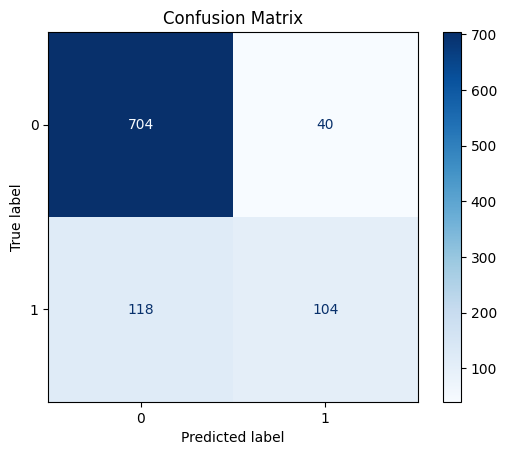

In [31]:
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = conf_matrix)
disp.plot(cmap = "Blues")
plt.title("Confusion Matrix")
plt.show()

In [32]:
feature_importances = grid_search.best_estimator_["classifier"].feature_importances_

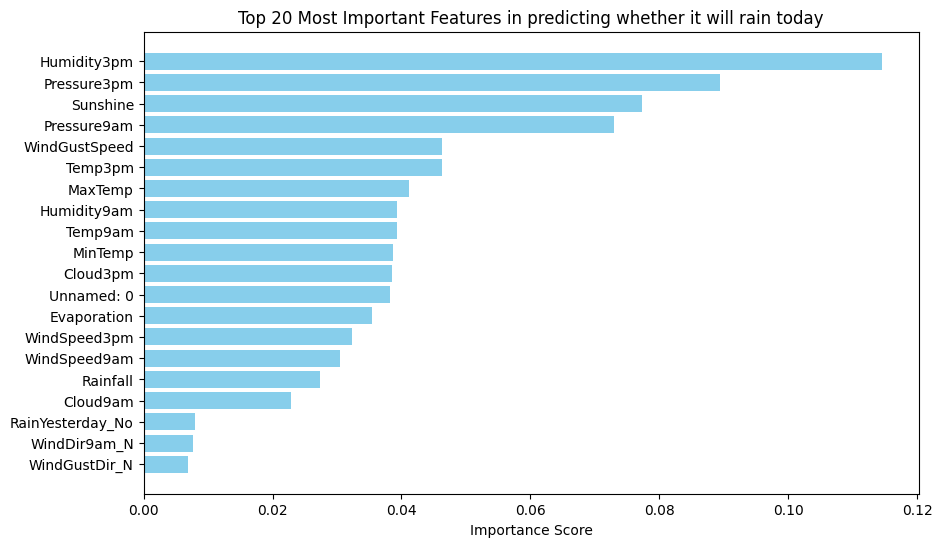

In [34]:
# Combine numeric and categorical feature names
feature_names = numerical_features + list(grid_search.best_estimator_['preprocessor']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

feature_importances = grid_search.best_estimator_['classifier'].feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances
                             }).sort_values(by='Importance', ascending=False)

N = 20  # Change this number to display more or fewer features
top_features = importance_df.head(N)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.title(f'Top {N} Most Important Features in predicting whether it will rain today')
plt.xlabel('Importance Score')
plt.show()

In [35]:
# Replacing RandomForestClassifier with LogisticRegression
pipeline.set_params(classifier=LogisticRegression(random_state=42))

grid_search.estimator = pipeline  # update the model's estimator to use the new pipeline

# Define a new grid with Logistic Regression parameters
param_grid = {
    'classifier__solver' : ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight' : [None, 'balanced']
}
grid_search.param_grid = param_grid

grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=No

              precision    recall  f1-score   support

          No       0.86      0.92      0.89       744
         Yes       0.67      0.51      0.58       222

    accuracy                           0.83       966
   macro avg       0.77      0.72      0.74       966
weighted avg       0.82      0.83      0.82       966



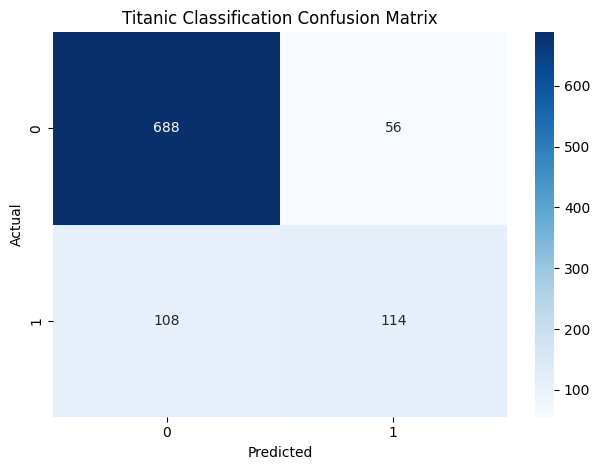

In [36]:
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')

plt.title('Titanic Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

Both models perform similarly with **Random Forest** slightly edging out in accuracy **(84% vs 83%)**. However, **Logistic Regression** shows a small improvement in recall for rainy days **(51% vs 47%)**, making it marginally better for the specific goal of predicting when rain will occur. Given the imbalanced dataset `(71% no rain, 29% rain)`, neither model excels at detecting rainy days — a trade-off common with accuracy-focused metrics.